In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [11]:
df = pd.read_csv('D600 Task 1 Dataset 1 Housing Information.csv')
df

,ID,Price,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,...,RenovationQuality,LocalAmenities,TransportAccess,Fireplace,HouseColor,Garage,Floors,Windows,PreviousSalePrice,IsLuxury
0,4922,255614.8992,566.62,1.000000,4,779.42,20.56,5.62,39.46,10.08,...,4.93,4.44,4.55,Yes,Blue,No,1,13,181861.54230,0
1,5009,155586.0947,1472.34,1.000000,2,656.13,15.62,5.63,40.51,7.89,...,4.08,5.56,6.83,No,Green,No,1,17,50042.59757,0
2,4450,131050.8324,550.00,1.779354,3,754.57,12.47,9.20,48.38,23.74,...,4.26,8.07,8.48,Yes,Green,Yes,2,34,48400.34440,0
3,1070,151361.7125,941.81,2.035254,2,439.59,22.22,7.08,94.67,5.22,...,4.45,5.00,6.27,Yes,Red,No,1,14,84594.12145,0
4,400,113167.6128,550.00,1.064644,3,353.03,8.28,5.93,16.80,43.13,...,3.36,5.46,6.99,No,White,Yes,1,21,22934.59654,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,6987,307821.1758,550.00,2.111022,4,892.35,11.89,7.97,28.18,19.23,...,4.76,3.81,6.87,No,White,Yes,1,18,241131.63070,1
6996,6995,421368.8869,1726.12,4.056115,2,943.19,34.06,5.82,90.45,17.60,...,5.31,9.84,10.00,No,White,Yes,1,18,481604.80730,1
6997,6996,473382.5348,1026.36,2.077177,5,149.31,0.10,8.81,31.79,11.59,...,4.98,7.47,2.96,No,Green,No,1,13,380555.49390,1
6998,6998,343397.9756,2218.22,1.000000,4,526.81,11.18,9.20,15.21,3.96,...,4.68,7.66,6.12,No,Blue,Yes,1,10,442610.31710,0


In [13]:
selected_vars = [
    'SquareFootage',
    'NumBathrooms',
    'NumBedrooms',
    'RenovationQuality',
    'PreviousSalePrice']

In [15]:
desc = df[selected_vars + ['Price']].describe().T
mode = df[selected_vars + ['Price']].mode().iloc[0].to_frame(name='mode')
desc_stats = desc.join(mode)
print(desc_stats)

                    count           mean            std           min  \
SquareFootage      7000.0    1048.947459     426.010482    550.000000   
NumBathrooms       7000.0       2.131397       0.952561      1.000000   
NumBedrooms        7000.0       3.008571       1.021940      1.000000   
RenovationQuality  7000.0       5.003357       1.970428      0.010000   
PreviousSalePrice  7000.0  284509.353128  185734.016770  -8356.902464   
Price              7000.0  307281.972151  150173.433261  85000.000000   

                             25%            50%            75%           max  \
SquareFootage         660.815000     996.320000    1342.292500  2.874700e+03   
NumBathrooms            1.290539       1.997774       2.763997  5.807239e+00   
NumBedrooms             2.000000       3.000000       4.000000  7.000000e+00   
RenovationQuality       3.660000       5.020000       6.350000  1.000000e+01   
PreviousSalePrice  142013.977225  262183.133450  396121.169350  1.296607e+06   
Price   

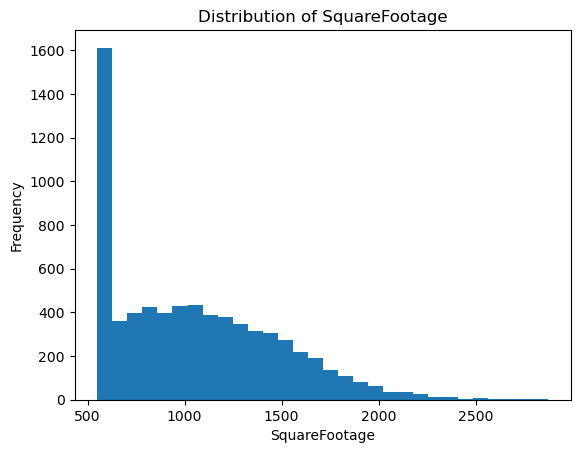

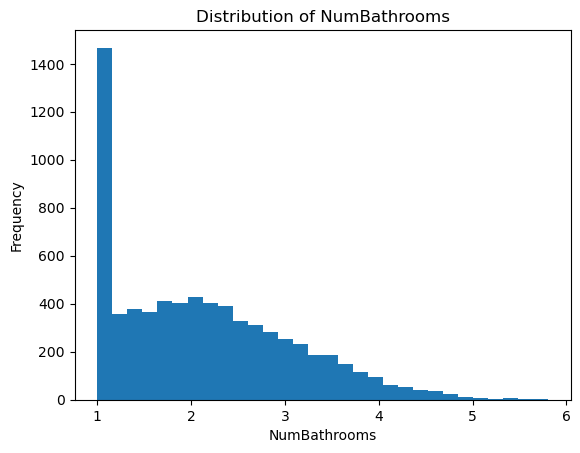

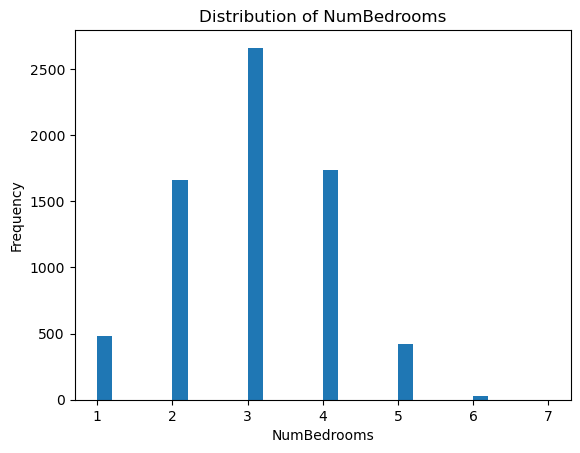

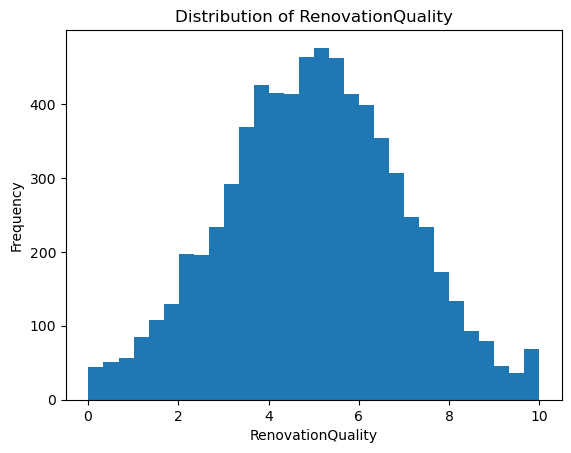

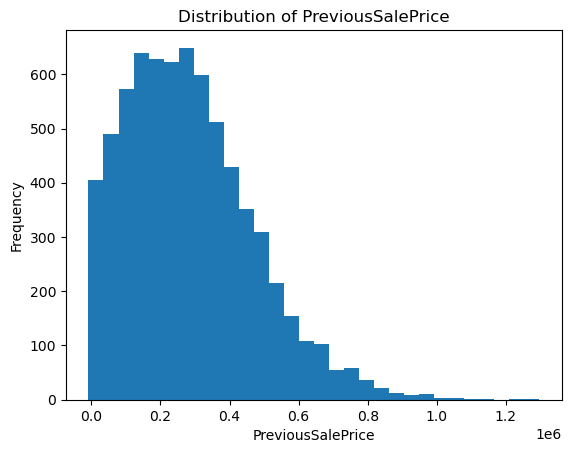

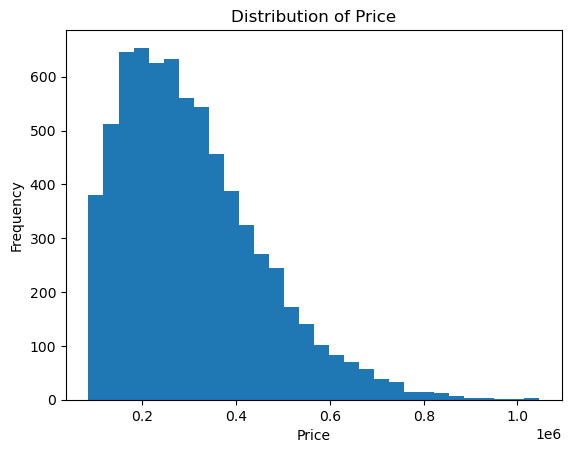

In [17]:
for var in selected_vars + ['Price']:
    plt.figure()
    plt.hist(df[var].dropna(), bins=30)
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()

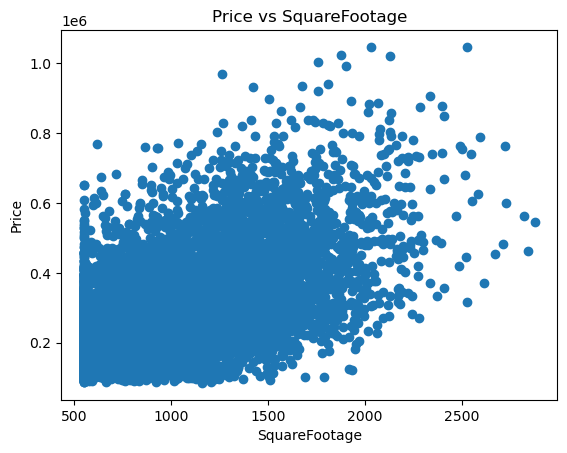

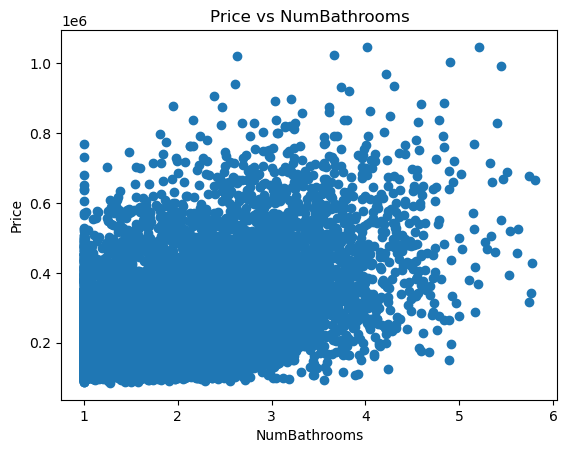

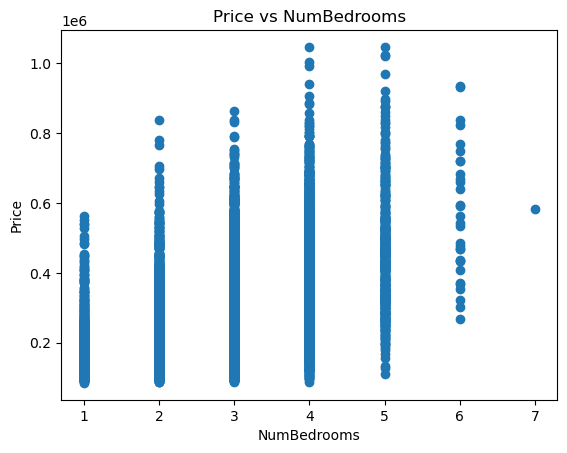

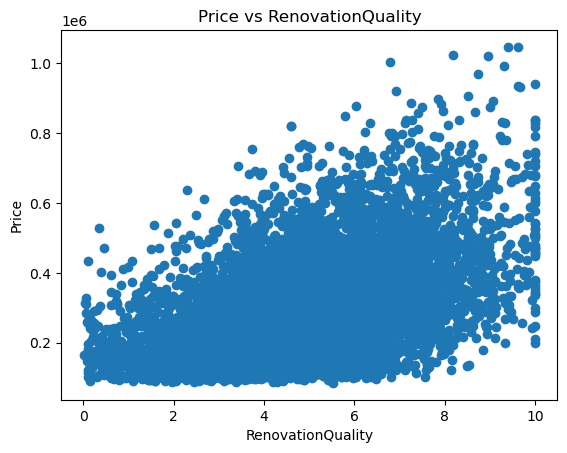

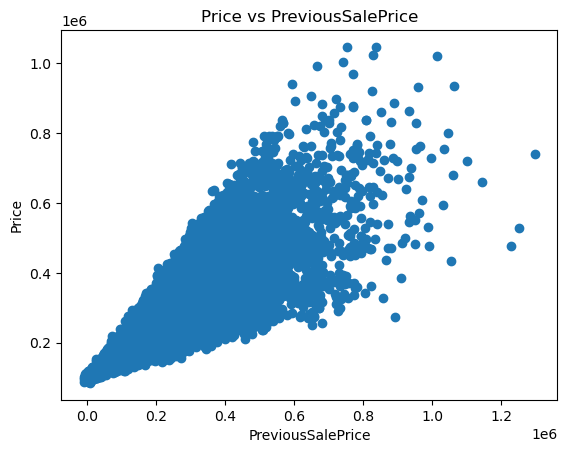

In [19]:
for var in selected_vars:
    plt.figure()
    plt.scatter(df[var], df['Price'])
    plt.title(f'Price vs {var}')
    plt.xlabel(var)
    plt.ylabel('Price')
    plt.show()

In [21]:
X = df[selected_vars]
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
X_train.assign(Price=y_train).to_csv('training_set.csv', index=False)
X_test.assign(Price=y_test).to_csv('test_set.csv', index=False)

In [25]:
selected = X_train.columns.tolist()
X_train_sm = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_sm).fit()

In [27]:
while True:
    pvals = model.pvalues.drop('const')
    max_p = pvals.max()
    if max_p <= 0.05:
        break
    remove_var = pvals.idxmax()
    selected_vars.remove(remove_var)
    X_train_sm = sm.add_constant(X_train[selected_vars])
    model = sm.OLS(y_train, X_train_sm).fit()

In [29]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.704
Model:                            OLS   Adj. R-squared:                  0.703
Method:                 Least Squares   F-statistic:                     2657.
Date:                Thu, 17 Jul 2025   Prob (F-statistic):               0.00
Time:                        16:43:40   Log-Likelihood:                -71332.
No. Observations:                5600   AIC:                         1.427e+05
Df Residuals:                    5594   BIC:                         1.427e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -8289.1154   5795.83

In [31]:
X_train_final = sm.add_constant(X_train[selected_vars])
X_test_final = sm.add_constant(X_test[selected_vars])
y_pred_train = model.predict(X_train_final)
y_pred_test = model.predict(X_test_final)

mse_train = mean_squared_error(y_train, y_pred_train)
print("Selected predictors:", selected_vars)
print(f"Training MSE: {mse_train:.2f}")

Selected predictors: ['SquareFootage', 'NumBathrooms', 'NumBedrooms', 'RenovationQuality', 'PreviousSalePrice']
Training MSE: 6783173748.57


In [33]:
mse_test = mean_squared_error(y_test, y_pred_test)
print("Selected predictors:", selected_vars)
print(f"Test MSE: {mse_test:.2f}")

Selected predictors: ['SquareFootage', 'NumBathrooms', 'NumBedrooms', 'RenovationQuality', 'PreviousSalePrice']
Test MSE: 6763141751.24


In [35]:
coef_table = pd.DataFrame({
    'Coef':       model.params,
    'StdErr':     model.bse,
    't-value':    model.tvalues,
    'P>|t|':      model.pvalues,
    'CI Lower':   model.conf_int().iloc[:, 0],
    'CI Upper':   model.conf_int().iloc[:, 1]
})
print(coef_table)

                           Coef       StdErr    t-value         P>|t|  \
const              -8289.115449  5795.835290  -1.430185  1.527198e-01   
SquareFootage         57.196783     3.490308  16.387316  5.480610e-59   
NumBathrooms       20567.416647  1415.275392  14.532448  5.374208e-47   
NumBedrooms        21401.183978  1353.031534  15.817210  3.660806e-55   
RenovationQuality   3411.969736   674.011869   5.062180  4.277565e-07   
PreviousSalePrice      0.459095     0.010627  43.199628  0.000000e+00   

                       CI Lower      CI Upper  
const             -19651.202265   3072.971368  
SquareFootage         50.354424     64.039142  
NumBathrooms       17792.927541  23341.905754  
NumBedrooms        18748.716995  24053.650962  
RenovationQuality   2090.644857   4733.294616  
PreviousSalePrice      0.438262      0.479929  


In [37]:
residuals = model.resid
fitted = model.fittedvalues
standardized_resid = (residuals - residuals.mean()) / residuals.std()

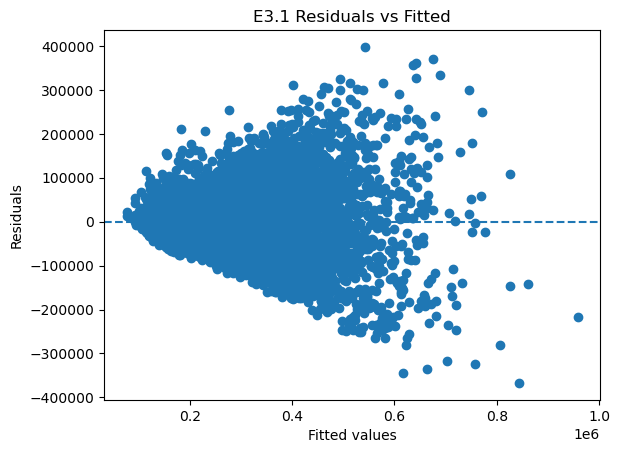

In [39]:
plt.figure()
plt.scatter(fitted, residuals)
plt.axhline(0, linestyle='--')
plt.title('E3.1 Residuals vs Fitted')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.show()

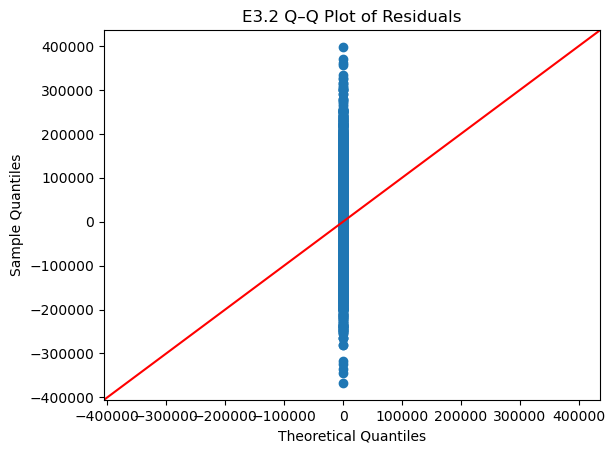

In [41]:
qqplot(residuals, line='45')
plt.title('E3.2 Q–Q Plot of Residuals')
plt.show()

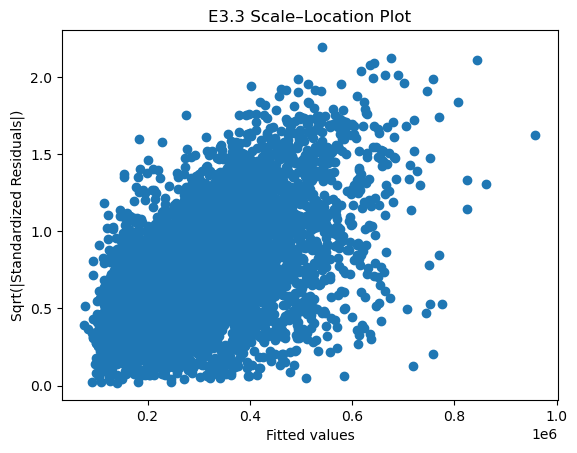

In [43]:
plt.figure()
plt.scatter(fitted, np.sqrt(np.abs(standardized_resid)))
plt.title('E3.3 Scale–Location Plot')
plt.xlabel('Fitted values')
plt.ylabel('Sqrt(|Standardized Residuals|)')
plt.show()

In [45]:
jb_stat, jb_p, skew, kurt = jarque_bera(residuals)
print(f"\nE3.4 Jarque–Bera statistic: {jb_stat:.3f}, p-value: {jb_p:.3f}")


E3.4 Jarque–Bera statistic: 517.720, p-value: 0.000


In [47]:
X_diag = sm.add_constant(X_train[selected])
vif_df = pd.DataFrame({
    'feature': X_diag.columns,
    'VIF': [variance_inflation_factor(X_diag.values, i) for i in range(X_diag.shape[1])]})
print("\nE3.5 Variance Inflation Factors:")
print(vif_df)


E3.5 Variance Inflation Factors:
             feature        VIF
0              const  27.702668
1      SquareFootage   1.821359
2       NumBathrooms   1.512222
3        NumBedrooms   1.598617
4  RenovationQuality   1.458132
5  PreviousSalePrice   3.241625
